<a href="https://colab.research.google.com/github/Halith0612/GUVI-Mini-Project-3/blob/Data-Collection-and-Cleaning/Ecotype2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# **Feature Engineering**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/df_cleaned.csv")

df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29
4,2579,132,6,300,-15,67,230,237,140,6031,Lodgepole Pine,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119950,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
119951,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
119952,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
119953,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29


In [3]:
df.shape

(119955, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119955 entries, 0 to 119954
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           119955 non-null  int64 
 1   Aspect                              119955 non-null  int64 
 2   Slope                               119955 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    119955 non-null  int64 
 4   Vertical_Distance_To_Hydrology      119955 non-null  int64 
 5   Horizontal_Distance_To_Roadways     119955 non-null  int64 
 6   Hillshade_9am                       119955 non-null  int64 
 7   Hillshade_Noon                      119955 non-null  int64 
 8   Hillshade_3pm                       119955 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  119955 non-null  int64 
 10  Cover_Type                          119955 non-null  object
 11  Wilderness_Area                     119

In [5]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

**Direction Table in Degree**
| Aspect (°) | Direction |
| ---------- | --------- |
| 0° / 360°  | North     |
| 45°        | Northeast |
| 90°        | East      |
| 135°       | Southeast |
| 180°       | South     |
| 225°       | Southwest |
| 270°       | West      |
| 315°       | Northwest |


In [6]:
df['Aspect']

,Aspect
0,51
1,56
2,139
3,45
4,132
...,...
119950,88
119951,68
119952,80
119953,121


**Direction(column_name) is not available in this dataset insted of that we can see Aspect(colunm_name), so that I created Direction(column_name) for clear understanding**


**8 directions and its degrees**
| Direction | Degrees |
| --------- | ------- |
| N         | 0°      |
| NE        | 45°     |
| E         | 90°     |
| SE        | 135°    |
| S         | 180°    |
| SW        | 225°    |
| W         | 270°    |
| NW        | 315°    |


In [7]:
def degree_to_direction(degree):
  if degree >= 0 and degree < 45:
    return "N"
  elif degree >= 45 and degree < 90:
    return "NE"
  elif degree >= 90 and degree < 135:
    return "E"
  elif degree >= 135 and degree < 180:
    return "SE"
  elif degree >= 180 and degree < 225:
    return "S"
  elif degree >= 225 and degree < 270:
    return "SW"
  elif degree >= 270 and degree < 315:
    return "W"
  else:
    return "NW"

In [8]:
df["Direction"] = df["Aspect"].apply(degree_to_direction)

In [9]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Direction
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29,NE
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29,NE
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12,SE
3,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29,NE
4,2579,132,6,300,-15,67,230,237,140,6031,Lodgepole Pine,1,29,E


In [10]:
# adding diffrence between sunlight shades
df["Shade_Diff"] = (df[['Hillshade_9am', 'Hillshade_Noon','Hillshade_3pm']].max(axis=1) - df[['Hillshade_9am', 'Hillshade_Noon','Hillshade_3pm']].min(axis=1))
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Direction,Shade_Diff
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29,NE,84
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29,NE,84
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12,SE,103
3,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29,NE,84
4,2579,132,6,300,-15,67,230,237,140,6031,Lodgepole Pine,1,29,E,97


In [11]:
# adding actual distance of hydrology
df["Distance_To_Hydrology"] = np.sqrt(df["Horizontal_Distance_To_Hydrology"]**2 + df["Vertical_Distance_To_Hydrology"]**2)

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Direction,Shade_Diff,Distance_To_Hydrology
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29,NE,84,258.000000
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29,NE,84,212.084889
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12,SE,103,275.769832
3,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29,NE,84,153.003268
4,2579,132,6,300,-15,67,230,237,140,6031,Lodgepole Pine,1,29,E,97,300.374766


In [12]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type', 'Direction', 'Shade_Diff', 'Distance_To_Hydrology'],
      dtype='object')

In [13]:
# reordering columns to easy access
df = df[['Cover_Type', 'Wilderness_Area','Soil_Type', 'Elevation', 'Direction', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
         'Vertical_Distance_To_Hydrology', 'Distance_To_Hydrology', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
         'Shade_Diff', 'Horizontal_Distance_To_Roadways','Horizontal_Distance_To_Fire_Points']]

df.head()

,Cover_Type,Wilderness_Area,Soil_Type,Elevation,Direction,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Distance_To_Hydrology,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Shade_Diff,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points
0,Aspen,1,29,2596,NE,51,3,258,0,258.000000,221,232,148,84,510,6279
1,Aspen,1,29,2590,NE,56,2,212,-6,212.084889,220,235,151,84,390,6225
2,Lodgepole Pine,1,12,2804,SE,139,9,268,65,275.769832,234,238,135,103,3180,6121
3,Aspen,1,29,2595,NE,45,2,153,-1,153.003268,220,234,150,84,391,6172
4,Lodgepole Pine,1,29,2579,E,132,6,300,-15,300.374766,230,237,140,97,67,6031


# **EDA**

In [14]:
df

,Cover_Type,Wilderness_Area,Soil_Type,Elevation,Direction,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Distance_To_Hydrology,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Shade_Diff,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points
0,Aspen,1,29,2596,NE,51,3,258,0,258.000000,221,232,148,84,510,6279
1,Aspen,1,29,2590,NE,56,2,212,-6,212.084889,220,235,151,84,390,6225
2,Lodgepole Pine,1,12,2804,SE,139,9,268,65,275.769832,234,238,135,103,3180,6121
3,Aspen,1,29,2595,NE,45,2,153,-1,153.003268,220,234,150,84,391,6172
4,Lodgepole Pine,1,29,2579,E,132,6,300,-15,300.374766,230,237,140,97,67,6031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119950,Lodgepole Pine,1,29,2834,NE,88,8,376,44,378.565714,232,227,128,104,2552,1595
119951,Lodgepole Pine,1,29,2832,NE,68,4,390,44,392.474203,224,231,142,89,2522,1572
119952,Lodgepole Pine,1,29,2829,NE,80,7,390,33,391.393664,229,228,133,96,2492,1550
119953,Lodgepole Pine,1,29,2826,E,121,7,379,30,380.185481,232,234,135,99,2462,1528


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

***1. Target Variable Distribution***

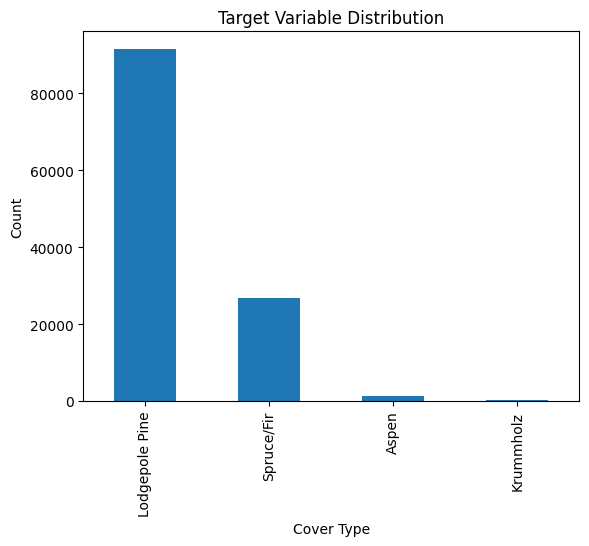

In [16]:
df["Cover_Type"].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.show()

**We can see "Lodgepole Pine" has high value_count compared to other cover_type**

***2. Elevation vs Cover Type***

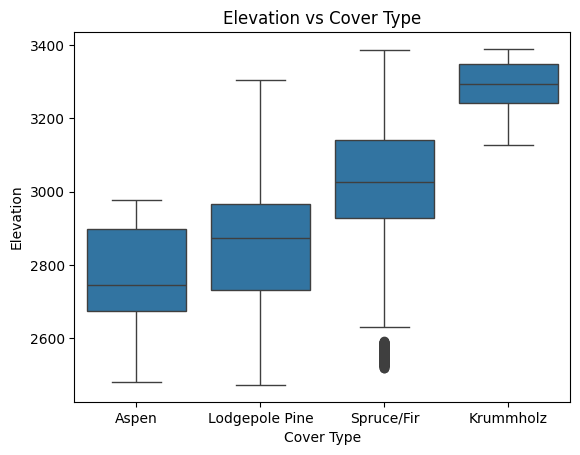

In [17]:
sns.boxplot(x="Cover_Type", y="Elevation", data=df)
plt.title("Elevation vs Cover Type")
plt.xlabel("Cover Type")
plt.ylabel("Elevation")
plt.show()

**Krummholz has Higher elevation than other.**

***3. Direction vs Sunlight at 9am***

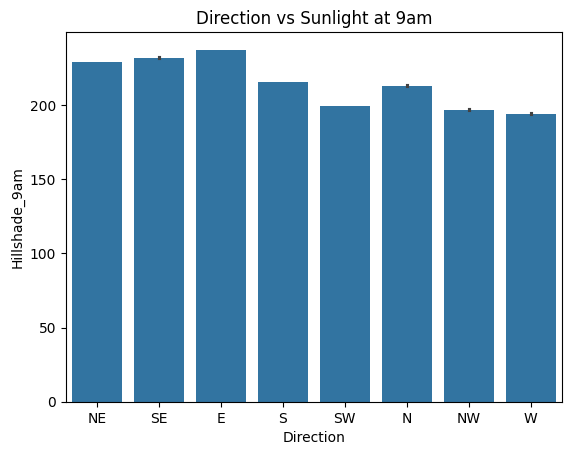

In [18]:
sns.barplot(x="Direction", y="Hillshade_9am", data=df)
plt.title("Direction vs Sunlight at 9am")
plt.xlabel("Direction")
plt.ylabel("Hillshade_9am")
plt.show()

**1. E, SE, and NE have the highest hillshade values, meaning these directions receive the most sunlight at 9AM — consistent with the sun rising in the east.**

**2. W and NW show lower values, indicating less direct sunlight at that time.**

***4. Sunlight Corelation - 9am, Noon & 3m***

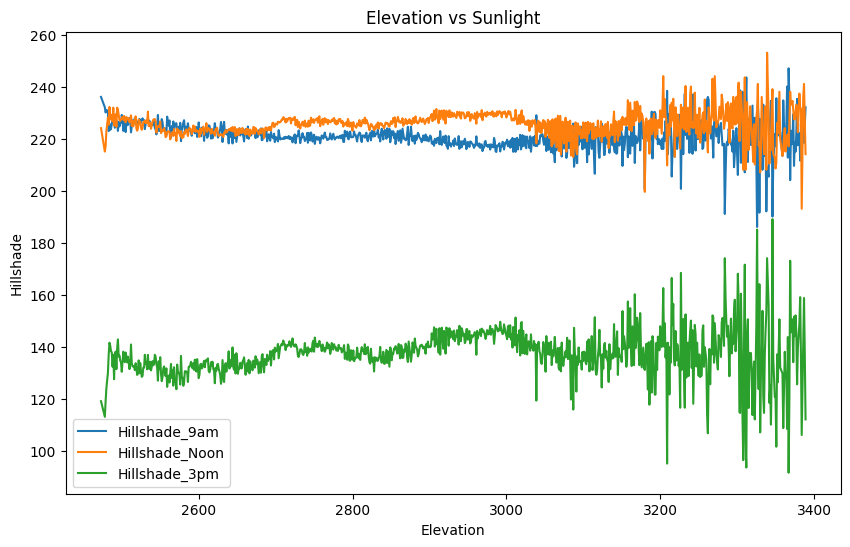

In [19]:
ele = df.groupby("Elevation")[["Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm"]].mean()

plt.figure(figsize=(10, 6))
plt.plot(ele.index, ele["Hillshade_9am"], label="Hillshade_9am")
plt.plot(ele.index, ele["Hillshade_Noon"], label="Hillshade_Noon")
plt.plot(ele.index, ele["Hillshade_3pm"], label="Hillshade_3pm")
plt.xlabel("Elevation")
plt.ylabel("Hillshade")
plt.title("Elevation vs Sunlight")
plt.legend()
plt.show()

**1. Here we can see stable sunlight at noon especially elevation between 3200 to 3400**

**2. More Flecuation at 3pm, might be elevation or vegitation**

***5. Corelation***

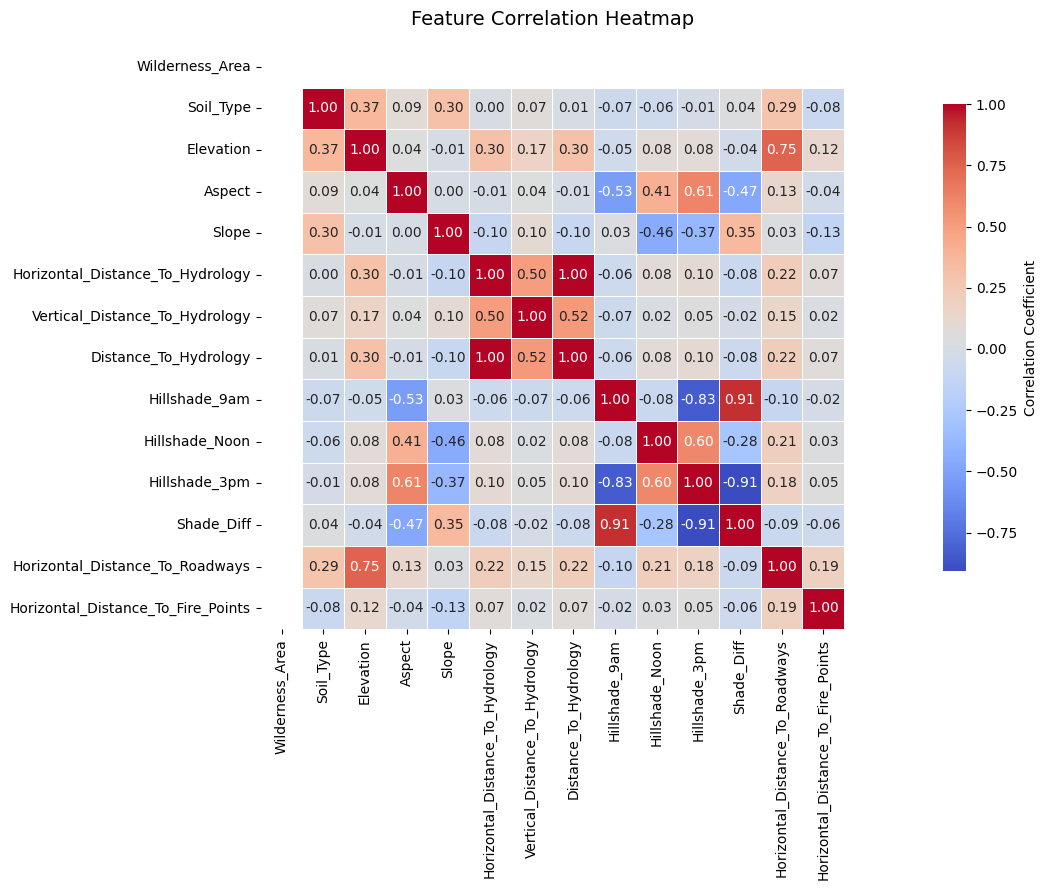

In [20]:
# Compute correlation matrix only for numeric columns
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(20, 9))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,          # show correlation values
    fmt=".2f",           # format numbers to 2 decimals
    linewidths=0.5,      # add grid lines for clarity
    square=True,         # make cells square
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)
plt.title("Feature Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


**Key Observations**

**1. Soil_Type ↔ Horizontal_Distance_To_Roadways (0.75) → strong positive link. Certain soil types are more common near or far from roads.**

**2. Hillshade_9am ↔ Hillshade_3pm (-0.83) → strong negative correlation. Morning and afternoon sunlight patterns are opposite due to terrain orientation.**

**3. Vertical_Distance_To_Hydrology ↔ Distance_To_Hydrology (0.52) → moderate positive correlation. Areas farther horizontally from water are also higher vertically.**

**4. Elevation ↔ Horizontal_Distance_To_Roadways (0.75) → higher elevations tend to be farther from roads.**

**5. Shade_Diff ↔ Hillshade_9am (-0.47) → negative correlation — steep or shaded areas differ in morning brightness.**

***6. Which Forest far away from Fire Point***

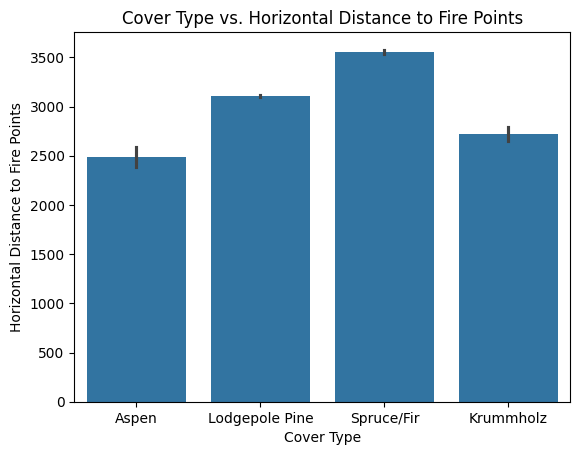

In [21]:
sns.barplot(x="Cover_Type", y="Horizontal_Distance_To_Fire_Points", data=df)
plt.title("Cover Type vs. Horizontal Distance to Fire Points")
plt.xlabel("Cover Type")
plt.ylabel("Horizontal Distance to Fire Points")
plt.show()


**1. Spruce/Fir is far more furtherest compared than other areas**

**2. Also Aspen has nearest fire points**

***7. Which are the Areas faraway from Human Accessabilty***

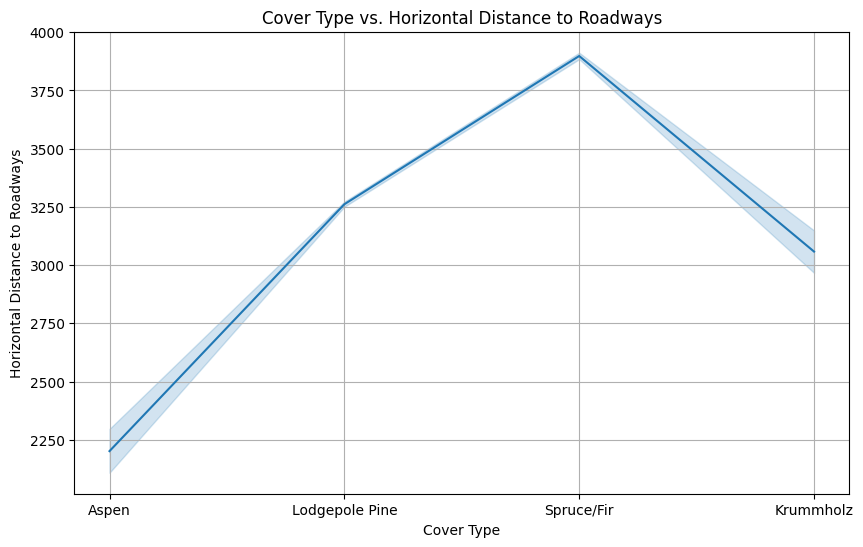

In [22]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="Cover_Type", y="Horizontal_Distance_To_Roadways", data=df)
plt.title("Cover Type vs. Horizontal Distance to Roadways")
plt.xlabel("Cover Type")
plt.ylabel("Horizontal Distance to Roadways")
plt.grid(True)
plt.show()

**Spruce/Fir being farthest from roads suggests these forests thrive in remote, higher-elevation zones with less human disturbance.**

***8. Highest Sunlight @3pm***

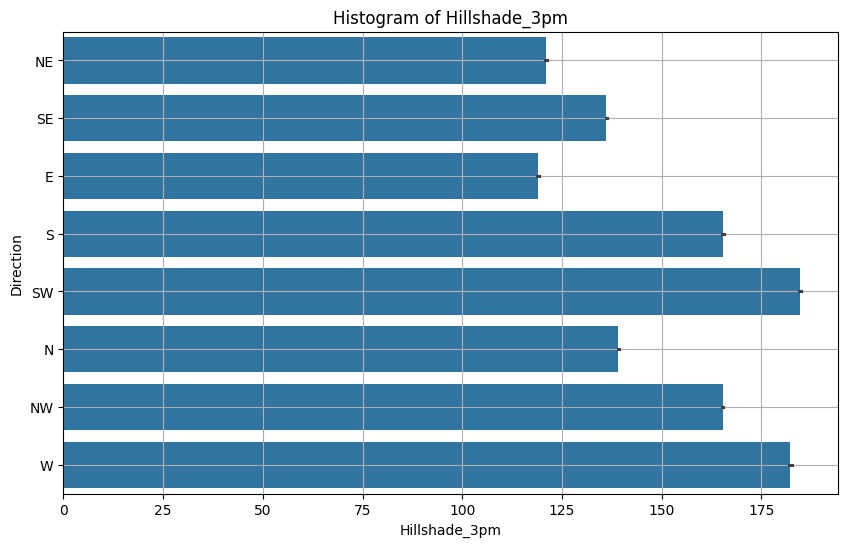

In [23]:
plt.figure(figsize = (10, 6))
sns.barplot(x = "Hillshade_3pm", y = "Direction", data = df)
plt.title("Histogram of Hillshade_3pm")
plt.xlabel("Hillshade_3pm")
plt.ylabel("Direction")
plt.grid(True)
plt.show()

**Even at 3pm SW, W faced forests are Highly seems Sunlight exposure**

***9. Highly elevated foest faced to the North direction***

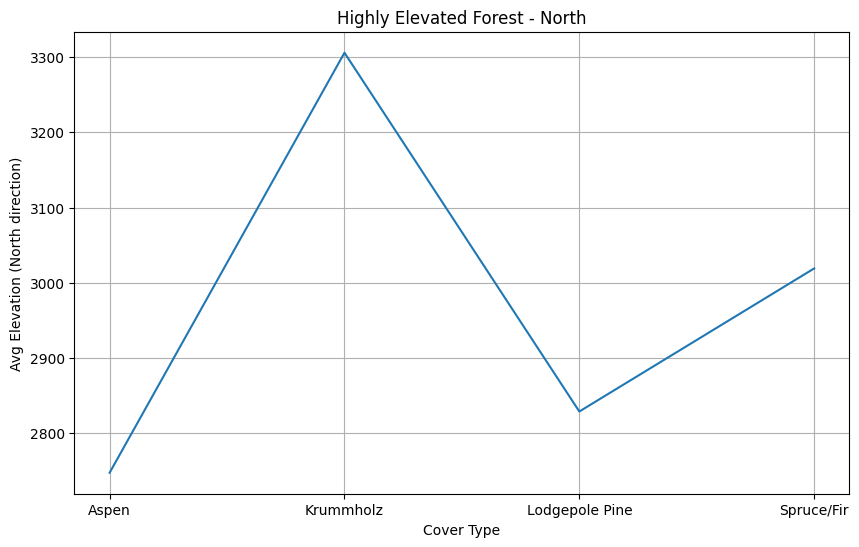

In [24]:
north_df = df[df["Direction"] == "N"]

high = north_df.groupby("Cover_Type")["Elevation"].mean()

plt.figure(figsize=(10,6))
plt.plot(high.index, high.values)
plt.xlabel("Cover Type")
plt.ylabel("Avg Elevation (North direction)")
plt.title("Highly Elevated Forest - North")
plt.grid()


**Aspen grows at lower elevations — it likes gentler slopes and warmer conditions.**

**Krummholz is found at the highest elevation — it’s a hardy, twisted tree that survives cold, windy mountain tops.**

**Lodgepole Pine sits lower again, showing it prefers mid-level terrain.**

**Spruce/Fir climbs back up — these trees can handle cooler, higher zones but not the extreme heights of Krummholz.**

***10. Corelation between Slop and Vertical Distance to Water***

<Axes: xlabel='Slope', ylabel='Vertical_Distance_To_Hydrology'>

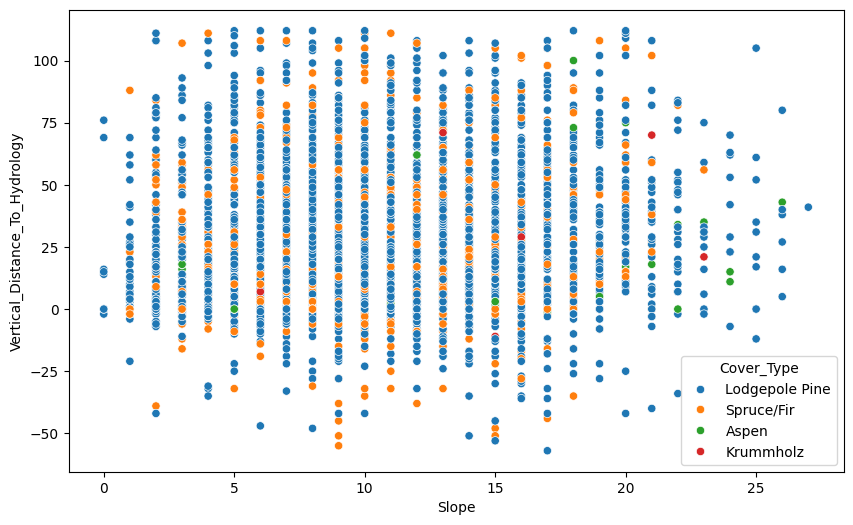

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(5000),
    x="Slope",
    y="Vertical_Distance_To_Hydrology",
    hue="Cover_Type"
)


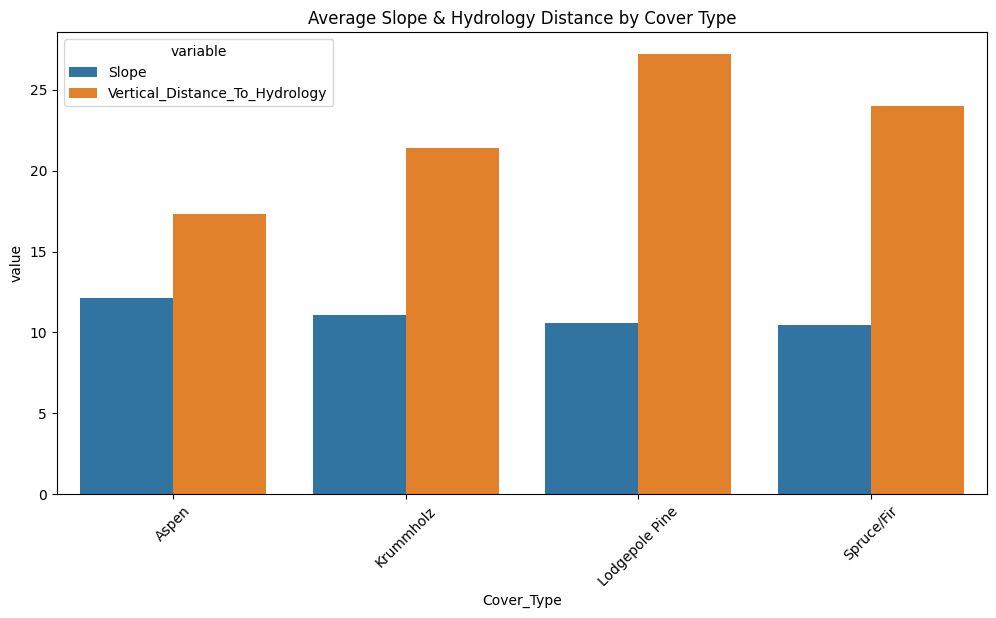

In [26]:
avg = df.groupby("Cover_Type")[["Slope", "Vertical_Distance_To_Hydrology"]].mean().reset_index()

avg_melted = avg.melt(id_vars="Cover_Type")

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_melted, x="Cover_Type", y="value", hue="variable")
plt.xticks(rotation=45)
plt.title("Average Slope & Hydrology Distance by Cover Type")
plt.show()

**Aspen has the steepest slopes but is closest to water (smaller vertical distance).**

**Krummholz grows on slightly gentler slopes and is farther from water.**

**Lodgepole Pine and Spruce/Fir both occur on gentle slopes, but they are much farther from hydrology — especially Lodgepole Pine, which shows the largest vertical distance.**

# **Encoding, Class Imbalance Handeling & Feature Importance**

In [27]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder # LabelEncoder, OneHotEncoder are OrdinalEncoder these are preprocessing tool from scikit-learn that converts categorical values into numbers.
from sklearn.ensemble import RandomForestClassifier

In [28]:
df.dtypes # checking data types for encoding

,0
Cover_Type,object
Wilderness_Area,int64
Soil_Type,int64
Elevation,int64
Direction,object
Aspect,int64
Slope,int64
Horizontal_Distance_To_Hydrology,int64
Vertical_Distance_To_Hydrology,int64
Distance_To_Hydrology,float64


In [29]:
df1 = df.copy()

In [30]:
df1.head()

,Cover_Type,Wilderness_Area,Soil_Type,Elevation,Direction,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Distance_To_Hydrology,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Shade_Diff,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points
0,Aspen,1,29,2596,NE,51,3,258,0,258.000000,221,232,148,84,510,6279
1,Aspen,1,29,2590,NE,56,2,212,-6,212.084889,220,235,151,84,390,6225
2,Lodgepole Pine,1,12,2804,SE,139,9,268,65,275.769832,234,238,135,103,3180,6121
3,Aspen,1,29,2595,NE,45,2,153,-1,153.003268,220,234,150,84,391,6172
4,Lodgepole Pine,1,29,2579,E,132,6,300,-15,300.374766,230,237,140,97,67,6031


In [31]:
df1['Direction'].unique()

array(['NE', 'SE', 'E', 'S', 'SW', 'N', 'NW', 'W'], dtype=object)

In [32]:
direction_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]

# Define Encoder with Custom Order
ordinal_encoder = OrdinalEncoder(categories=[direction_order])

# Fit and Transform
df1['Direction'] = ordinal_encoder.fit_transform(df1[['Direction']])

df1['Direction'] = df1['Direction'].astype(int)

In [33]:
df1['Cover_Type'].unique()

array(['Aspen', 'Lodgepole Pine', 'Spruce/Fir', 'Krummholz'], dtype=object)

In [34]:
le = LabelEncoder()

df1['Cover_Type'] = le.fit_transform(df1[['Cover_Type']])

df1['Cover_Type'] = df1['Cover_Type'].astype(int)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [35]:
df1.head()

,Cover_Type,Wilderness_Area,Soil_Type,Elevation,Direction,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Distance_To_Hydrology,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Shade_Diff,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points
0,0,1,29,2596,1,51,3,258,0,258.000000,221,232,148,84,510,6279
1,0,1,29,2590,1,56,2,212,-6,212.084889,220,235,151,84,390,6225
2,2,1,12,2804,3,139,9,268,65,275.769832,234,238,135,103,3180,6121
3,0,1,29,2595,1,45,2,153,-1,153.003268,220,234,150,84,391,6172
4,2,1,29,2579,2,132,6,300,-15,300.374766,230,237,140,97,67,6031


In [36]:
X = df1.drop(columns="Cover_Type")
y = df1["Cover_Type"]

# train a random forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# display top features
feature_importance_df

,Feature,Importance
2,Elevation,0.274848
13,Horizontal_Distance_To_Roadways,0.168829
14,Horizontal_Distance_To_Fire_Points,0.155741
1,Soil_Type,0.059850
7,Vertical_Distance_To_Hydrology,0.053564
8,Distance_To_Hydrology,0.053428
6,Horizontal_Distance_To_Hydrology,0.042315
4,Aspect,0.036625
10,Hillshade_Noon,0.033097
11,Hillshade_3pm,0.030747


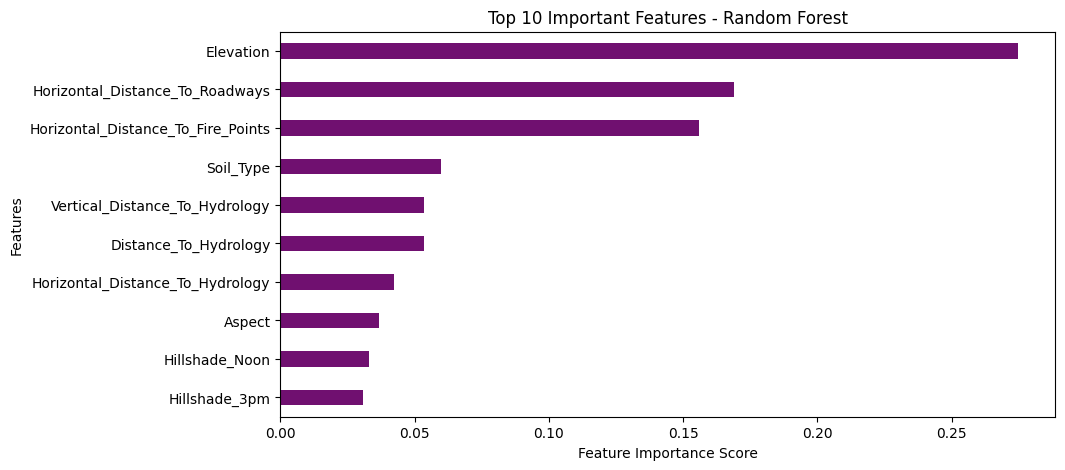

In [37]:
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance_df['Importance'][:10], y=feature_importance_df['Feature'][:10], color='purple', width=0.4)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")
plt.show()

In [38]:
feature_importance_df['Feature'][:10].tolist()

['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Soil_Type',
 'Vertical_Distance_To_Hydrology',
 'Distance_To_Hydrology',
 'Horizontal_Distance_To_Hydrology',
 'Aspect',
 'Hillshade_Noon',
 'Hillshade_3pm']

In [39]:
top10 =  ['Elevation', 'Horizontal_Distance_To_Roadways', 'Horizontal_Distance_To_Fire_Points','Soil_Type',
          'Vertical_Distance_To_Hydrology', 'Distance_To_Hydrology', 'Horizontal_Distance_To_Hydrology',
          'Aspect', 'Hillshade_Noon', 'Hillshade_3pm', 'Cover_Type']

filtered_df = df1[top10]

filtered_df.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Soil_Type,Vertical_Distance_To_Hydrology,Distance_To_Hydrology,Horizontal_Distance_To_Hydrology,Aspect,Hillshade_Noon,Hillshade_3pm,Cover_Type
0,2596,510,6279,29,0,258.000000,258,51,232,148,0
1,2590,390,6225,29,-6,212.084889,212,56,235,151,0
2,2804,3180,6121,12,65,275.769832,268,139,238,135,2
3,2595,391,6172,29,-1,153.003268,153,45,234,150,0
4,2579,67,6031,29,-15,300.374766,300,132,237,140,2


In [40]:
filtered_df.to_csv("/content/drive/MyDrive/df_encoded.csv", index=False)